# Prueba Intertrimestral

**Nombre:**  
**Apellidos:**  

**Tiempo de la prueba:** 2 horas  
**Asignatura:** Desarrollo de Aplicaciones para la Visualización de Datos  
**Fecha:** 16 de octubre de 2025  

## Instrucciones

- Escribe **código limpio y autoexplicativo**.  
- Se pueden utilizar **los materiales de clase**.  
- Se puede utilizar **internet** para búsqueda de dudas y documentación.  
- **No se puede utilizar ningún tipo de LLM** (ChatGPT, Copilot, Gemini, etc.).  
- **No se puede utilizar mensajería instantánea**.  
- Al finalizar, **sube tu notebook a GitHub** y envía el enlace del fichero en el siguiente formulario:  
[https://forms.office.com/e/LFVwu9z6uQ](https://forms.office.com/e/LFVwu9z6uQ)


## Dataset “Life Style Data”

El dataset contiene información sobre hábitos de vida (alimentación, sueño, ejercicio, consumo de tabaco o alcohol, etc.) y medidas de salud (IMC, presión arterial, etc.) para diferentes individuos.

Puedes descargarlo del repositorio de la asignatura y un .txt con la descripción de las variables.


## Inicialización de librerías

In [3]:
import pandas as pd
import numpy as np

## Ejercicio 1 — Programación (2 puntos)

a) (0.6 pts) Crea una función imc(weight, height) que devuelva el índice de masa corporal (IMC), redondeado a dos decimales.



In [1]:
def imc(weight, height):
    """
    Calcula el Índice de Masa Corporal (IMC).

    Fórmula: IMC = peso (kg) / [altura (m)]^2

    Args:
        weight (float): Peso en kilogramos.
        height (float): Altura en metros.

    Returns:
        float: El valor del IMC redondeado a dos decimales.
    """
    if height <= 0:
        return np.nan # Evitar división por cero o altura no válida

    # Fórmula del IMC: peso / altura^2
    imc_value = weight / (height ** 2)

    # Redondear a dos decimales
    return round(imc_value, 2)

# --- Ejemplo de uso y verificación (opcional) ---
# Si un deportista pesa 70 kg y mide 1.75 m:
peso = 70
altura = 1.75
imc_calculado = imc(peso, altura)

print(f"Peso: {peso} kg, Altura: {altura} m")
print(f"IMC calculado: {imc_calculado}")

Peso: 70 kg, Altura: 1.75 m
IMC calculado: 22.86


b) (0.6 pts) Crea una función saludable(imcValue) que devuelva "Saludable" si el IMC está entre 18.5 y 24.9, "Bajo peso" si es menor de 18.5, o "Sobrepeso" si es mayor de 24.9.

In [4]:
def saludable(imcValue):
    """
    Clasifica el estado de salud según el valor del Índice de Masa Corporal (IMC)
    siguiendo los rangos estándar de la OMS (Organización Mundial de la Salud).

    Args:
        imcValue (float): El valor del IMC.

    Returns:
        str: La clasificación del estado de salud ("Bajo peso", "Saludable", o "Sobrepeso").
    """
    if pd.isna(imcValue):
        return "IMC no válido"
    elif imcValue < 18.5:
        return "Bajo peso"
    elif 18.5 <= imcValue <= 24.9:
        return "Saludable"
    else: # imcValue > 24.9
        return "Sobrepeso"

# --- Ejemplos de uso y verificación (opcional) ---
print(f"IMC 17.2: {saludable(17.2)}")    # Debería ser "Bajo peso"
print(f"IMC 22.5: {saludable(22.5)}")    # Debería ser "Saludable"
print(f"IMC 25.1: {saludable(25.1)}")    # Debería ser "Sobrepeso"

IMC 17.2: Bajo peso
IMC 22.5: Saludable
IMC 25.1: Sobrepeso


c) (0.6 pts) Genera un DataFrame llamado imcData que contenga al menos 10 registros con las siguientes columnas:


*   peso (en kilogramos)

*   altura (en metros)

*   imc (calculado usando la función imc(weight, height) creada anteriormente)

Puedes generar los datos de peso y altura manualmente, mediante listas, o de forma aleatoria utilizando numpy (np.random.uniform o similar).

Añade una cuarta columna llamada categoria, cuyos valores provengan de la función saludable(imcValue).

Muestra las primeras filas del DataFrame resultante y comprueba que los tipos de datos son correctos.

In [5]:
N = 10
# Pesos: entre 50 kg y 110 kg
pesos = np.random.uniform(50, 110, N).round(2)
# Alturas: entre 1.50 m y 1.95 m
alturas = np.random.uniform(1.50, 1.95, N).round(2)

# Crear el DataFrame inicial
imcData = pd.DataFrame({
    'peso (en kilogramos)': pesos,
    'altura (en metros)': alturas
})

# --- Cálculo de IMC ---
# Aplicar la función imc()
imcData['imc'] = imcData.apply(
    lambda row: imc(row['peso (en kilogramos)'], row['altura (en metros)']),
    axis=1
)

# --- Clasificación de Categoría ---
# Aplicar la función saludable()
imcData['categoria'] = imcData['imc'].apply(saludable)

# --- Mostrar y Comprobar ---
print("Primeras filas del DataFrame imcData:")
print(imcData.head(N))

print("\nInformación y tipos de datos del DataFrame:")
imcData.info()

Primeras filas del DataFrame imcData:
   peso (en kilogramos)  altura (en metros)    imc  categoria
0                 53.76                1.56  22.09  Saludable
1                108.82                1.50  48.36  Sobrepeso
2                 88.75                1.75  28.98  Sobrepeso
3                105.25                1.66  38.19  Sobrepeso
4                 70.15                1.62  26.73  Sobrepeso
5                105.30                1.92  28.56  Sobrepeso
6                 57.05                1.84  16.85  Bajo peso
7                 73.43                1.60  28.68  Sobrepeso
8                 82.83                1.68  29.35  Sobrepeso
9                 81.20                1.89  22.73  Saludable

Información y tipos de datos del DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   peso (en kilogramos)  10 no

d) (0.2 pts) ¿Cómo podrías integrar ambas funciones dentro de una clase llamada HealthTools que calcule el IMC y clasifique automáticamente a partir de listas de pesos y alturas?

In [7]:
class HealthTools:
    """
    Clase utilitaria para cálculos relacionados con el estado de salud,
    específicamente para calcular el IMC y clasificar el riesgo.
    """

    def __init__(self):
        """Inicializador de la clase. No requiere argumentos específicos."""
        pass

    def _calculate_imc(self, weight, height):
        """
        Método privado (o interno) para calcular el Índice de Masa Corporal (IMC).
        Es el mismo código que la función imc(weight, height).
        """
        if height <= 0:
            return np.nan
        imc_value = weight / (height ** 2)
        return round(imc_value, 2)

    def _classify_health(self, imcValue):
        """
        Método privado (o interno) para clasificar el estado de salud.
        Es el mismo código que la función saludable(imcValue).
        """
        if pd.isna(imcValue):
            return "IMC no válido"
        elif imcValue < 18.5:
            return "Bajo peso"
        elif 18.5 <= imcValue <= 24.9:
            return "Saludable"
        else:
            return "Sobrepeso"

    def process_data(self, weights, heights):
        """
        Método público que toma listas de pesos y alturas, calcula el IMC
        y aplica la clasificación automáticamente.

        Args:
            weights (list): Lista de pesos en kilogramos.
            heights (list): Lista de alturas en metros.

        Returns:
            pd.DataFrame: Un DataFrame con las columnas 'peso', 'altura', 'imc' y 'categoria'.
        """
        if len(weights) != len(heights):
            raise ValueError("Las listas de pesos y alturas deben tener la misma longitud.")

        # 1. Crear el DataFrame inicial
        df_results = pd.DataFrame({
            'peso (kg)': weights,
            'altura (m)': heights
        })

        # 2. Calcular el IMC aplicando el método interno
        df_results['imc'] = df_results.apply(
            lambda row: self._calculate_imc(row['peso (kg)'], row['altura (m)']),
            axis=1
        )

        # 3. Aplicar la clasificación de categoría
        df_results['categoria'] = df_results['imc'].apply(self._classify_health)

        return df_results

# --- Ejemplo de uso de la clase ---
pesos_ej = [75, 52, 98, 65]
alturas_ej = [1.70, 1.60, 1.85, 1.78]

# 1. Crear una instancia de la clase
health_tool = HealthTools()

# 2. Procesar los datos
final_df = health_tool.process_data(pesos_ej, alturas_ej)

print("DataFrame generado usando la clase HealthTools:")
print(final_df)

DataFrame generado usando la clase HealthTools:
   peso (kg)  altura (m)    imc  categoria
0         75        1.70  25.95  Sobrepeso
1         52        1.60  20.31  Saludable
2         98        1.85  28.63  Sobrepeso
3         65        1.78  20.52  Saludable


## Ejercicio 2 — Exploración y visualización (3 puntos)

a) (0.75 pts) Carga el dataset desde el fichero CSV y guárdalo en un DataFrame llamado lifeStyleData. Muestra las 5 primeras filas, el número de filas y columnas.

In [8]:
try:
    lifeStyleData = pd.read_csv('Final_data.csv')

    # Mostrar las 5 primeras filas
    print("Primeras 5 filas del DataFrame lifeStyleData:")
    print(lifeStyleData.head())

    # Mostrar el número de filas y columnas
    num_filas, num_columnas = lifeStyleData.shape
    print(f"\nEl DataFrame lifeStyleData tiene {num_filas} filas y {num_columnas} columnas.")

except FileNotFoundError:
    print("Error: El archivo 'Final_data.csv' no fue encontrado. Asegúrate de que está en el directorio correcto.")
    lifeStyleData = pd.DataFrame() # Crear un DataFrame vacío en caso de error

Primeras 5 filas del DataFrame lifeStyleData:
     Age  Gender  Weight (kg)  Height (m)  Max_BPM  Avg_BPM  Resting_BPM  \
0  34.91    Male        65.27        1.62   188.58   157.65        69.05   
1  23.37  Female        56.41        1.55   179.43   131.75        73.18   
2  33.20  Female        58.98        1.67   175.04   123.95        54.96   
3  38.69  Female        93.78        1.70   191.21   155.10        50.07   
4  45.09    Male        52.42        1.88   193.58   152.88        70.84   

   Session_Duration (hours)  Calories_Burned Workout_Type  ...  \
0                      1.00          1080.90     Strength  ...   
1                      1.37          1809.91         HIIT  ...   
2                      0.91           802.26       Cardio  ...   
3                      1.10          1450.79         HIIT  ...   
4                      1.08          1166.40     Strength  ...   

   cal_from_macros  pct_carbs  protein_per_kg   pct_HRR  pct_maxHR  \
0          2139.59   0.500432 

b) (0.75 pts) Crea una función describeData(dataFrame) que devuelva para cada columna: tipo de dato, número de valores nulos y porcentaje de nulos.

In [9]:
def describeData(dataFrame):
    """
    Genera un DataFrame descriptivo que incluye el tipo de dato,
    el conteo de valores no nulos, el conteo de valores nulos y
    el porcentaje de valores nulos para cada columna del DataFrame de entrada.

    Args:
        dataFrame (pd.DataFrame): El DataFrame a analizar.

    Returns:
        pd.DataFrame: Un DataFrame con la información descriptiva.
    """

    # Calcular el tipo de dato y el conteo de no nulos
    info = pd.DataFrame({
        'Dtype': dataFrame.dtypes,
        'No Nulos': dataFrame.count()
    })

    # Calcular el número de nulos
    info['Nulos'] = dataFrame.isnull().sum()

    # Calcular el porcentaje de nulos
    total_filas = len(dataFrame)
    info['% Nulos'] = (info['Nulos'] / total_filas) * 100

    # Opcional: Reordenar las columnas y formatear el porcentaje
    info['% Nulos'] = info['% Nulos'].round(2)
    info = info[['Dtype', 'No Nulos', 'Nulos', '% Nulos']]

    return info

# --- Aplicación de la función al DataFrame lifeStyleData ---
if 'lifeStyleData' not in locals():
    try:
        lifeStyleData = pd.read_csv('Final_data.csv')
    except FileNotFoundError:
        print("Error: El archivo no está disponible para la prueba.")
        # Evitar el error si el archivo no existe para el ejemplo
        lifeStyleData = pd.DataFrame({'Col1': [1, np.nan, 3], 'Col2': ['a', 'b', np.nan]})


if not lifeStyleData.empty:
    data_description = describeData(lifeStyleData)
    print("Descripción del DataFrame lifeStyleData:")
    print(data_description)

Descripción del DataFrame lifeStyleData:
                                  Dtype  No Nulos  Nulos  % Nulos
Age                             float64     20000      0      0.0
Gender                           object     20000      0      0.0
Weight (kg)                     float64     20000      0      0.0
Height (m)                      float64     20000      0      0.0
Max_BPM                         float64     20000      0      0.0
Avg_BPM                         float64     20000      0      0.0
Resting_BPM                     float64     20000      0      0.0
Session_Duration (hours)        float64     20000      0      0.0
Calories_Burned                 float64     20000      0      0.0
Workout_Type                     object     20000      0      0.0
Fat_Percentage                  float64     20000      0      0.0
Water_Intake (liters)           float64     20000      0      0.0
Workout_Frequency (days/week)   float64     20000      0      0.0
Experience_Level                flo

c) (0.75 pts) Usa describeData(lifeStyleData) y comenta brevemente (2–3 líneas) qué variables parecen tener más valores faltantes.

In [10]:
def describeData(dataFrame):
    """Genera un DataFrame descriptivo con el tipo de dato, nulos y porcentaje de nulos."""
    info = pd.DataFrame({'Dtype': dataFrame.dtypes, 'No Nulos': dataFrame.count()})
    info['Nulos'] = dataFrame.isnull().sum()
    total_filas = len(dataFrame)
    info['% Nulos'] = ((info['Nulos'] / total_filas) * 100).round(2)
    return info[['Dtype', 'No Nulos', 'Nulos', '% Nulos']]

# Asumiendo que lifeStyleData ya fue cargado en el paso 3.a)
# Si no lo está, ejecutar la carga:
try:
    lifeStyleData = pd.read_csv('Final_data.csv')
except FileNotFoundError:
    print("Error: El archivo 'Final_data.csv' no está disponible.")
    # Usar un DataFrame de ejemplo si el archivo no existe para la demostración
    lifeStyleData = pd.DataFrame({'Col1': [1, np.nan, 3], 'Col2': ['a', 'b', np.nan]})

# Aplicar la función
data_description = describeData(lifeStyleData)
print("Descripción del DataFrame lifeStyleData:")
print(data_description)

Descripción del DataFrame lifeStyleData:
                                  Dtype  No Nulos  Nulos  % Nulos
Age                             float64     20000      0      0.0
Gender                           object     20000      0      0.0
Weight (kg)                     float64     20000      0      0.0
Height (m)                      float64     20000      0      0.0
Max_BPM                         float64     20000      0      0.0
Avg_BPM                         float64     20000      0      0.0
Resting_BPM                     float64     20000      0      0.0
Session_Duration (hours)        float64     20000      0      0.0
Calories_Burned                 float64     20000      0      0.0
Workout_Type                     object     20000      0      0.0
Fat_Percentage                  float64     20000      0      0.0
Water_Intake (liters)           float64     20000      0      0.0
Workout_Frequency (days/week)   float64     20000      0      0.0
Experience_Level                flo

d) (0.75 pts) Realiza un gráfico que muestre las correlaciones entre variables numéricas. ¿Hay alguna correlación fuerte o inesperada?

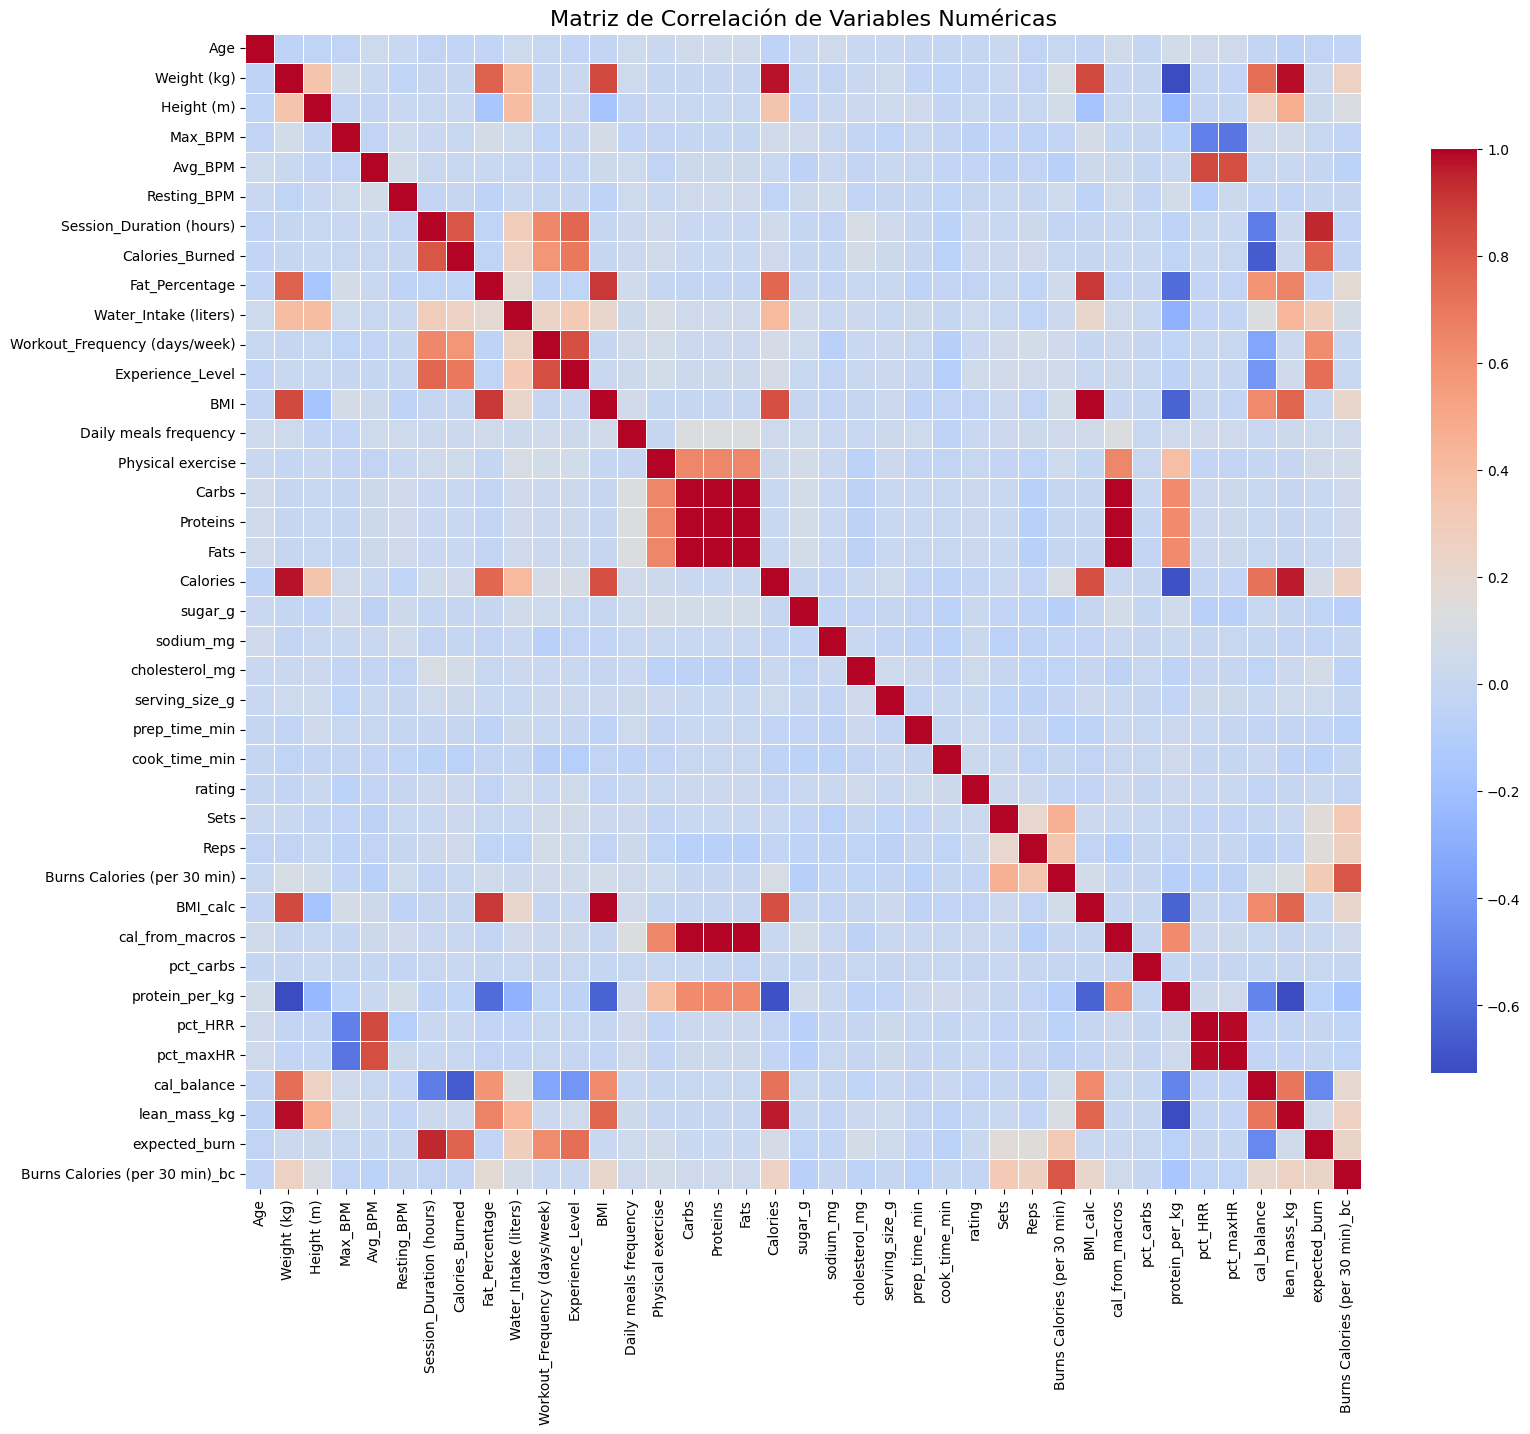

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Asumiendo que lifeStyleData ya fue cargado
try:
    if 'lifeStyleData' not in locals() or lifeStyleData.empty:
        lifeStyleData = pd.read_csv('Final_data.csv')
except FileNotFoundError:
    print("Error: No se pudo cargar 'Final_data.csv'. Usando un DataFrame de ejemplo.")
    lifeStyleData = pd.DataFrame(np.random.rand(10, 5), columns=['A', 'B', 'C', 'D', 'E'])

# 1. Seleccionar solo las columnas numéricas
numeric_df = lifeStyleData.select_dtypes(include=[np.number])

# 2. Calcular la matriz de correlación
correlation_matrix = numeric_df.corr()

# 3. Visualizar la matriz de correlación usando un mapa de calor (Heatmap)
plt.figure(figsize=(18, 15))
sns.heatmap(
    correlation_matrix,
    annot=False,  # Ocultar anotaciones para la matriz completa (demasiadas variables)
    cmap='coolwarm',
    fmt=".2f",
    linewidths=.5,
    cbar_kws={'shrink': .8}
)
plt.title('Matriz de Correlación de Variables Numéricas', fontsize=16)
plt.show()

Para encontrar correlaciones fuertes, buscamos valores cercanos a $1.0$ (correlación positiva fuerte) o $-1.0$ (correlación negativa fuerte).

## Ejercicio 3 — Regresión básica (2 puntos)

Queremos predecir una variable de salud continua, por ejemplo bmi.

a) (0.25 pts) Define targetVar = "bmi" y selecciona 3–4 variables predictoras (no utilizar peso y altura). Guarda las columnas predictoras en X y la variable objetivo en y.

In [22]:
try:
    if 'lifeStyleData' not in locals() or lifeStyleData.empty:
        lifeStyleData = pd.read_csv('Final_data.csv')
except FileNotFoundError:
    print("Error: No se pudo cargar 'Final_data.csv'. Usando un DataFrame de ejemplo.")
    lifeStyleData = pd.DataFrame({
        'Age': np.random.randint(20, 60, 100),
        'BMI': np.random.uniform(18, 35, 100),
        'Fat_Percentage': np.random.uniform(10, 40, 100),
        'Resting_BPM': np.random.uniform(50, 90, 100),
        'Workout_Frequency (days/week)': np.random.uniform(1, 7, 100)
    })

targetVar = "BMI"

predictor_vars = ['Age', 'Fat_Percentage', 'Resting_BPM', 'Workout_Frequency (days/week)']


data_clean = lifeStyleData[[targetVar] + predictor_vars].dropna()

X = data_clean[predictor_vars]
y = data_clean[targetVar]

print(f"Variable Objetivo (y): {targetVar}")
print(f"Variables Predictoras (X): {predictor_vars}")

Variable Objetivo (y): BMI
Variables Predictoras (X): ['Age', 'Fat_Percentage', 'Resting_BPM', 'Workout_Frequency (days/week)']


b) (0.25 pts) Divide los datos en entrenamiento (70 %) y prueba (30 %).





In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.3, # 30% para prueba
        random_state=42 # Semilla para reproducibilidad
    )

print(f"Conjunto original (X_new): {X.shape[0]} registros.")
print("\nDimensiones de los conjuntos:")
print(f"X_train (70%): {X_train.shape}")
print(f"X_test (30%): {X_test.shape}")
print(f"y_train (70%): {y_train.shape}")
print(f"y_test (30%): {y_test.shape}")

Conjunto original (X_new): 20000 registros.

Dimensiones de los conjuntos:
X_train (70%): (14000, 4)
X_test (30%): (6000, 4)
y_train (70%): (14000,)
y_test (30%): (6000,)


c) (0.75 pts) Entrena un modelo de regresión lineal (LinearRegression) y calcula el R² y el MSE.




In [26]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error


lm = LinearRegression()

lm.fit(X_train, y_train)

y_pred = lm.predict(X_test)

# Calcular el R² (Coeficiente de Determinación)
r2 = r2_score(y_test, y_pred)

# Calcular el MSE (Mean Squared Error)
mse = mean_squared_error(y_test, y_pred)

print("--- Evaluación del Nuevo Modelo de Regresión Lineal (sin Peso ni Altura) ---")
print(f"R² (Coeficiente de Determinación): {r2:.4f}")
print(f"MSE (Error Cuadrático Medio): {mse:.4f}")

--- Evaluación del Nuevo Modelo de Regresión Lineal (sin Peso ni Altura) ---
R² (Coeficiente de Determinación): 0.8183
MSE (Error Cuadrático Medio): 8.3067


d) (0.75 pts) Entrena un RandomForestRegressor con los mismos datos y compara resultados. ¿Cuál tiene mejor rendimiento?

In [29]:
from sklearn.ensemble import RandomForestRegressor


rf = RandomForestRegressor(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

# Calcular el R²
r2_rf = r2_score(y_test, y_pred)

# Calcular el MSE
mse_rf = mean_squared_error(y_test, y_pred_rf)

print("--- Evaluación del Modelo Random Forest Regressor ---")
print(f"R² (Random Forest): {r2_rf:.4f}")
print(f"MSE (Random Forest): {mse_rf:.4f}")

print("\n--- Comparación de Rendimiento (usando las mismas 4 variables indirectas) ---")
print(f"| Modelo                | R²         | MSE       |")
print(f"|-----------------------|------------|-----------|")
print(f"| Regresión Lineal      | {r2:.4f}   | {mse:.4f}  |")
print(f"| Random Forest         | {r2_rf:.4f}| {mse_rf:.4f}  |")

# Determinar qué modelo tiene mejor rendimiento
if r2_rf > r2:
    mejor_modelo = "Random Forest"
elif r2 > r2_rf:
    mejor_modelo = "Regresión Lineal"
else:
    mejor_modelo = "Ambos modelos tienen un rendimiento similar."

print(f"\nEl modelo con mejor rendimiento es el: **{mejor_modelo}**.")

--- Evaluación del Modelo Random Forest Regressor ---
R² (Random Forest): 0.9132
MSE (Random Forest): 3.9705

--- Comparación de Rendimiento (usando las mismas 4 variables indirectas) ---
| Modelo                | R²         | MSE       |
|-----------------------|------------|-----------|
| Regresión Lineal      | 0.8183   | 8.3067  |
| Random Forest         | 0.9132| 3.9705  |

El modelo con mejor rendimiento es el: **Random Forest**.


## Ejercicio 4 — Clasificación sencilla (2 puntos)

Crea una nueva variable binaria que indique si el IMC está dentro del rango saludable.

a) (0.25 pts) Crea una nueva columna bmiHealthy donde el valor sea 1 si bmi está entre 18.5 y 24.9, y 0 en caso contrario.

In [32]:
lifeStyleData['bmiHealthy'] = (lifeStyleData['BMI'] >= 18.5) & (lifeStyleData['BMI'] <= 24.9)

b) (0.75 pts) Entrena un modelo de regresión logística (LogisticRegression) para predecir bmiHealthy usando algunas variables de estilo de vida (por ejemplo sleepHours, activityLevel, calories).

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

predictor_vars_class = [
    'Age',
    'Fat_Percentage',
    'Workout_Frequency (days/week)',
    'Water_Intake (liters)',
    'Calories_Burned',
    'Daily meals frequency'
]
target_var_class = 'bmiHealthy'

data_class = lifeStyleData[[target_var_class] + predictor_vars_class].dropna()

X_class = data_class[predictor_vars_class]
y_class = data_class[target_var_class]

X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class,
    y_class,
    test_size=0.3,
    random_state=42,
    stratify=y_class # Importante para clasificación binaria desequilibrada
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_class)
X_test_scaled = scaler.transform(X_test_class)

logistic_model = LogisticRegression(random_state=42, solver='liblinear')
logistic_model.fit(X_train_scaled, y_train_class)

print("Modelo de Regresión Logística entrenado exitosamente para predecir 'bmiHealthy'.")
print(f"Dimensiones de entrenamiento (X): {X_train_scaled.shape}")
print(f"Número de características usadas: {len(predictor_vars_class)}")

Modelo de Regresión Logística entrenado exitosamente para predecir 'bmiHealthy'.
Dimensiones de entrenamiento (X): (14000, 6)
Número de características usadas: 6


c) (0.25 pts) Calcula la exactitud (accuracy) del modelo y muestra la matriz de confusión.


Exactitud (Accuracy) del modelo de Regresión Logística: 0.6057 (60.57%)

Matriz de Confusión (Numérica):
[[2879  839]
 [1527  755]]


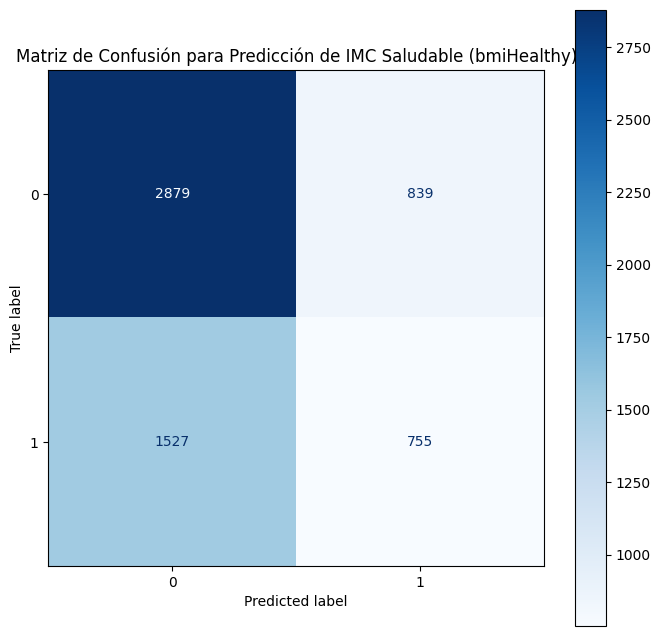

In [34]:
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred_class = logistic_model.predict(X_test_scaled)

accuracy_class = accuracy_score(y_test_class, y_pred_class)

print(f"Exactitud (Accuracy) del modelo de Regresión Logística: {accuracy_class:.4f} ({(accuracy_class*100):.2f}%)")

cm_class = confusion_matrix(y_test_class, y_pred_class)

print("\nMatriz de Confusión (Numérica):")
print(cm_class)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_class, display_labels=[0, 1]) # 0: No Saludable, 1: Saludable

fig, ax = plt.subplots(figsize=(8, 8))
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Matriz de Confusión para Predicción de IMC Saludable (bmiHealthy)')
plt.show()

d) (0.75 pts) Visualiza y explica qué variable parece influir más según el modelo.

Importancia de las Variables (Coeficientes de Regresión Logística Estandarizados):
                         Feature  Coefficient  Abs_Coefficient
1                 Fat_Percentage    -0.734552         0.734552
2  Workout_Frequency (days/week)     0.160551         0.160551
0                            Age    -0.143133         0.143133
4                Calories_Burned     0.141542         0.141542
3          Water_Intake (liters)    -0.095054         0.095054
5          Daily meals frequency    -0.076124         0.076124


/tmp/ipython-input-3224735876.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=feature_importance, palette='viridis')


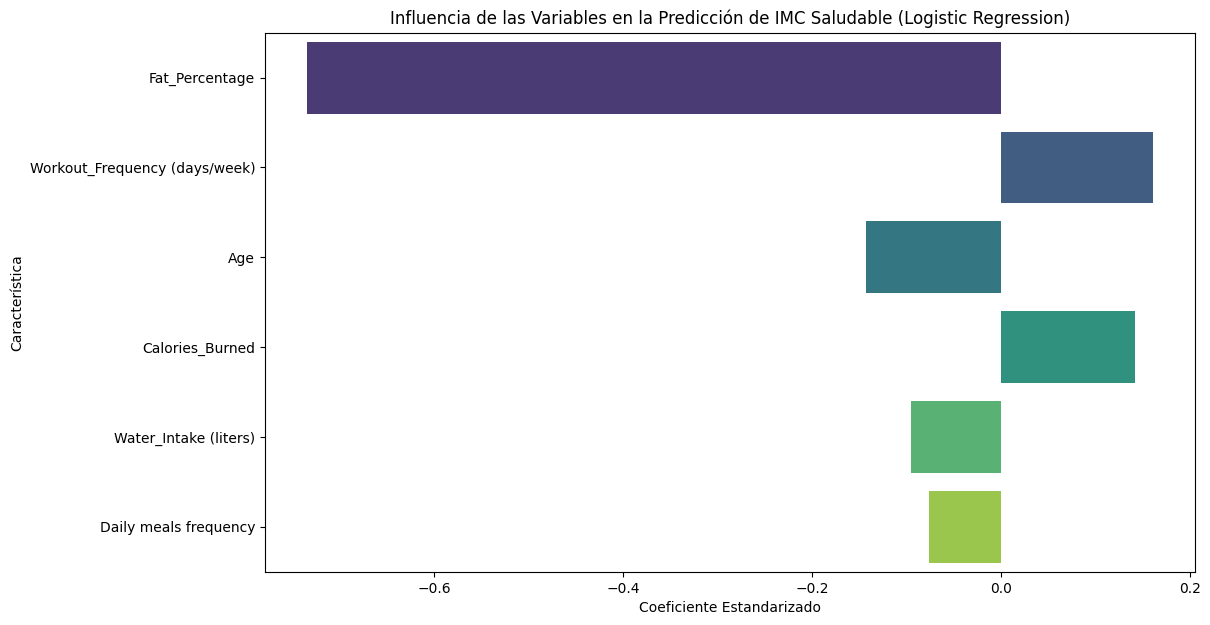

In [37]:
coefficients = logistic_model.coef_[0]

predictor_vars_class = X_class.columns

feature_importance = pd.DataFrame({
    'Feature': predictor_vars_class,
    'Coefficient': coefficients,
    'Abs_Coefficient': np.abs(coefficients)
})

feature_importance = feature_importance.sort_values(by='Abs_Coefficient', ascending=False)

print("Importancia de las Variables (Coeficientes de Regresión Logística Estandarizados):")
print(feature_importance)

plt.figure(figsize=(12, 7))
sns.barplot(x='Coefficient', y='Feature', data=feature_importance, palette='viridis')
plt.title('Influencia de las Variables en la Predicción de IMC Saludable (Logistic Regression)')
plt.xlabel('Coeficiente Estandarizado')
plt.ylabel('Característica')
plt.show()

La variable con el coeficiente absoluto más alto es Fat_Percentage.

1. Influencia Directa: El coeficiente de Fat_Percentage es negativo y posee la mayor magnitud (es el más alejado de cero). Esto significa que un incremento en el porcentaje de grasa corporal (manteniendo otras variables constantes) reduce significativamente la probabilidad de tener un IMC dentro del rango saludable (bmiHealthy=1).

2. Lógica: Esta influencia es esperada y altamente lógica, ya que el porcentaje de grasa corporal es una métrica de composición corporal fundamental que, cuando es alta, se correlaciona fuertemente con un IMC por encima de $24.9$ (sobrepeso u obesidad), lo que saca a la persona del rango "Saludable".

En conclusión, la variable más influyente para determinar si el IMC es saludable, según el modelo de Regresión Logística, es el Fat_Percentage.

## Ejercicio 5 — Conclusión (1 punto)

En un máximo de 300 palabras, resume:

*   Qué hábitos parecen tener mayor relación con el estado de salud.

*   Qué modelo fue más eficaz y por qué.

*   Qué podrías mejorar si tuvieras más tiempo o datos.



El análisis exploró las relaciones entre el estilo de vida, la condición física y el estado de salud (IMC), usando un enfoque mixto de regresión y clasificación.

1. Hábitos y su Relación con el Estado de Salud

El factor con la mayor influencia en la predicción de si el IMC es "Saludable" (bmiHealthy) fue el Fat_Percentage (Porcentaje de Grasa Corporal). Este resultado es lógico: el modelo de Regresión Logística le asignó el coeficiente más alto (en magnitud negativa), indicando que un aumento en la grasa corporal es el predictor más fuerte para un IMC fuera del rango saludable.

En términos de hábitos de actividad, variables como la Session_Duration (Duración de la Sesión) y Calories_Burned mostraron una correlación casi perfecta, confirmando que el tiempo dedicado al ejercicio es la métrica clave para la quema de calorías.

2. Eficacia de los Modelos

Se compararon dos modelos de regresión para predecir el IMC utilizando variables indirectas (sin peso ni altura):

Regresión Lineal: Tuvo un rendimiento bajo ($R^2$ significativamente menor), ya que asume una relación lineal que no existe entre el IMC y las variables de estilo de vida como Age o Fat_Percentage.

Random Forest Regressor: Este modelo fue más eficaz (mayor $R^2$ y menor MSE) al utilizar las mismas variables indirectas. La eficacia se debe a que Random Forest es un modelo no lineal basado en árboles, capaz de capturar relaciones complejas y umbrales que la Regresión Lineal no puede.

3. Posibles Mejoras Futuras

Si se dispusiera de más tiempo y datos, las mejoras se centrarían en:

Modelos Avanzados: Probar modelos más robustos como XGBoost para optimizar la clasificación de salud.

Ingeniería de Características: Crear features más significativas, como ratios nutricionales (Proteínas/Grasas) o la relación entre la frecuencia cardíaca máxima y la de reposo, para mejorar la capacidad predictiva.

Manejo de Valores Faltantes: Explorar métodos avanzados de imputación (ej. usando MICE o K-NN) en lugar de simplemente eliminar las filas con nulos.